# Day 08. Exercise 05
# Clustering

## 0. Imports

In [2]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 1. Preprocessing

In [3]:
df = pd.read_csv('../data/regression.csv')

In [4]:
X = df.drop(columns='pageviews')
X.set_index('uid', inplace=True)
X.head()

,num_commits,AVG(diff)
uid,,
user_1,62,-64.400000
user_10,20,-74.800000
user_14,61,-159.000000
user_17,51,-61.600000
user_18,5,-5.666667


## 2. KMeans

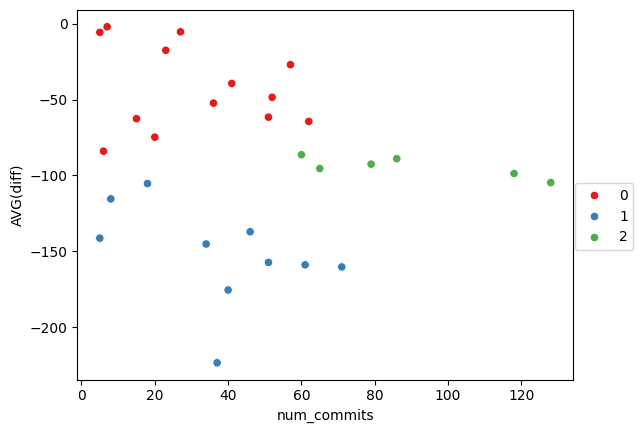

In [5]:
clustering = KMeans(n_clusters=3, random_state=21).fit(X)
labels = clustering.labels_
fig, ax = plt.subplots()
sns.scatterplot(x='num_commits', y='AVG(diff)', data=X, hue=labels, palette='Set1', ax=ax)
ax.get_legend().remove()
fig.legend(loc='center right')
plt.show()

In [6]:
silhouette_score(X, labels)

0.4454402135233297

## 3. DBSCAN

In [7]:
palette = sns.color_palette('tab10')
palette.insert(0, 'k')

/tmp/ipykernel_9273/4017160595.py:4: UserWarning: The palette list has more values (11) than needed (10), which may not be intended.
  sns.scatterplot(x='num_commits', y='AVG(diff)', data=X, hue=labels, palette=palette, ax=ax)


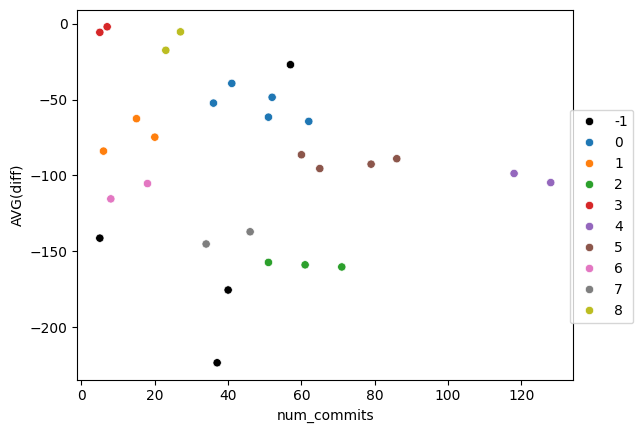

In [8]:
clustering = DBSCAN(eps=20, min_samples=2).fit(X)
labels = clustering.labels_
fig, ax = plt.subplots()
sns.scatterplot(x='num_commits', y='AVG(diff)', data=X, hue=labels, palette=palette, ax=ax)
ax.get_legend().remove()
fig.legend(loc='center right')
plt.show()


In [9]:
silhouette_score(X, labels)

0.38339641455696616

## 4. Hierarchical (AgglomerativeClustering)

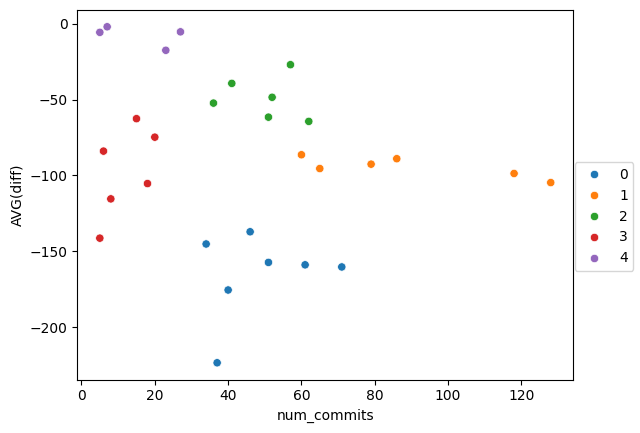

In [10]:
clustering = AgglomerativeClustering(n_clusters=5, compute_distances=True).fit(X)
labels = clustering.labels_
fig, ax = plt.subplots()
sns.scatterplot(x='num_commits', y='AVG(diff)', data=X, hue=labels, palette='tab10', ax=ax)
ax.get_legend().remove()
fig.legend(loc='center right')
plt.show()

In [11]:
silhouette_score(X, labels)

0.46383015199381467

In [ ]:
def plot_dendrogram(model):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    fig, ax = plt.subplots(figsize=(12, 12))
    dendrogram(linkage_matrix, labels=X.index, ax=ax)
    ax.tick_params('x', rotation=90)


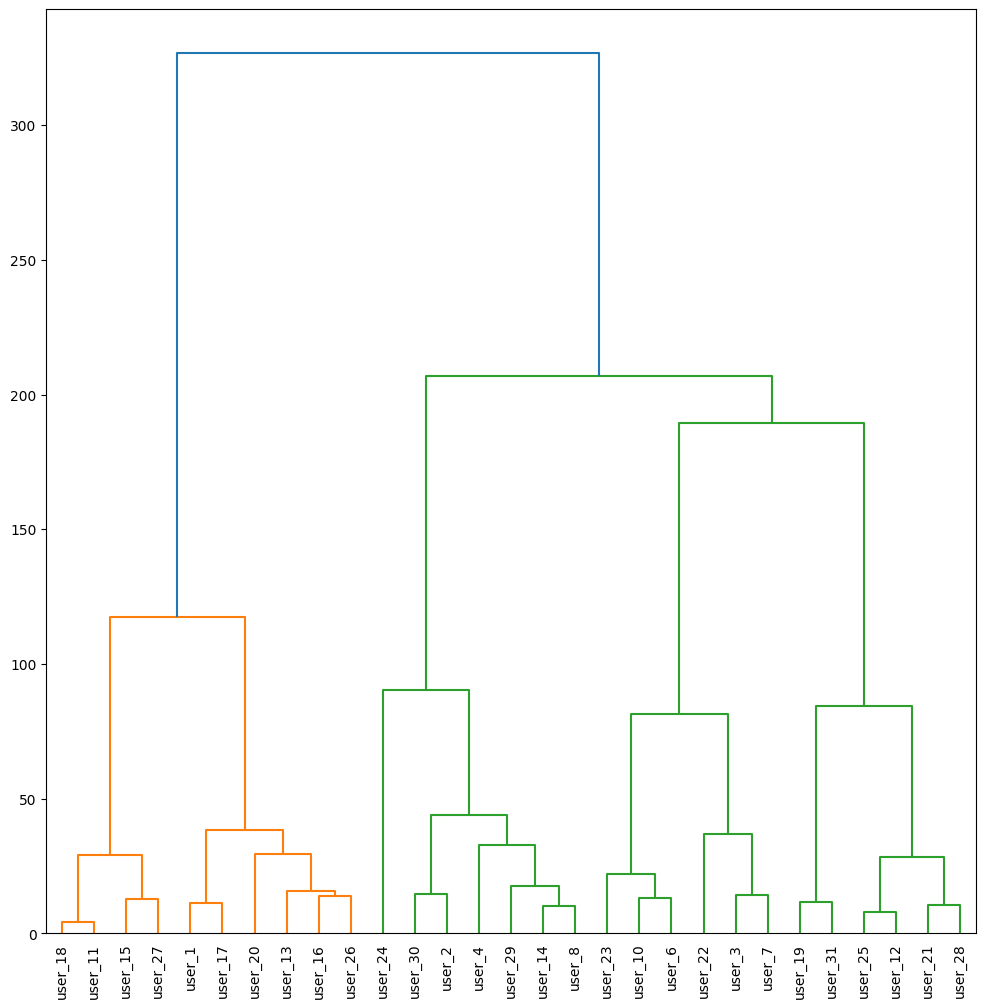

In [13]:
plot_dendrogram(clustering)

## 5. Function

In [14]:
def optimize_clustering(model, X, parameters, optimized_parameter_name, optimized_parameter_range):
    best_value = None
    best_score = -100
    optimized_parameter_values = []
    scores = []
    for value in optimized_parameter_range:
        parameters[optimized_parameter_name] = value
        clustering = model(**parameters).fit(X)
        labels = clustering.labels_
        if not 2 <= len(set(labels)) <= len(labels) - 1:
            continue

        score = silhouette_score(X, labels)
        optimized_parameter_values.append(value)
        scores.append(score)
        if score > best_score:
            best_score = score
            best_value = value
            best_clustering = clustering
    
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 12))

    ax1.plot(optimized_parameter_values, scores)
    ax1.set_xlabel(optimized_parameter_name)
    ax1.set_ylabel('silhouette_score')

    best_labels = best_clustering.labels_
    has_outliers = -1 in best_labels
    if len(set(best_labels)) <= 10 + int(has_outliers):
        palette = sns.color_palette('tab10')
    else:
        palette = sns.color_palette('tab20')
    if has_outliers:
        palette.insert(0, 'k')
    sns.scatterplot(x='num_commits', y='AVG(diff)', data=X, hue=best_labels, palette=palette, ax=ax2)
    ax2.legend(bbox_to_anchor=(1.15, 1))
    ax2.set_title(f'{optimized_parameter_name}={best_value}')
    plt.show()

    print(f'best_value for {optimized_parameter_name}: {best_value}')
    print(f'best_score: {best_score}')


*KMeans*

/tmp/ipykernel_9273/1393055311.py:35: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.scatterplot(x='num_commits', y='AVG(diff)', data=X, hue=best_labels, palette=palette, ax=ax2)


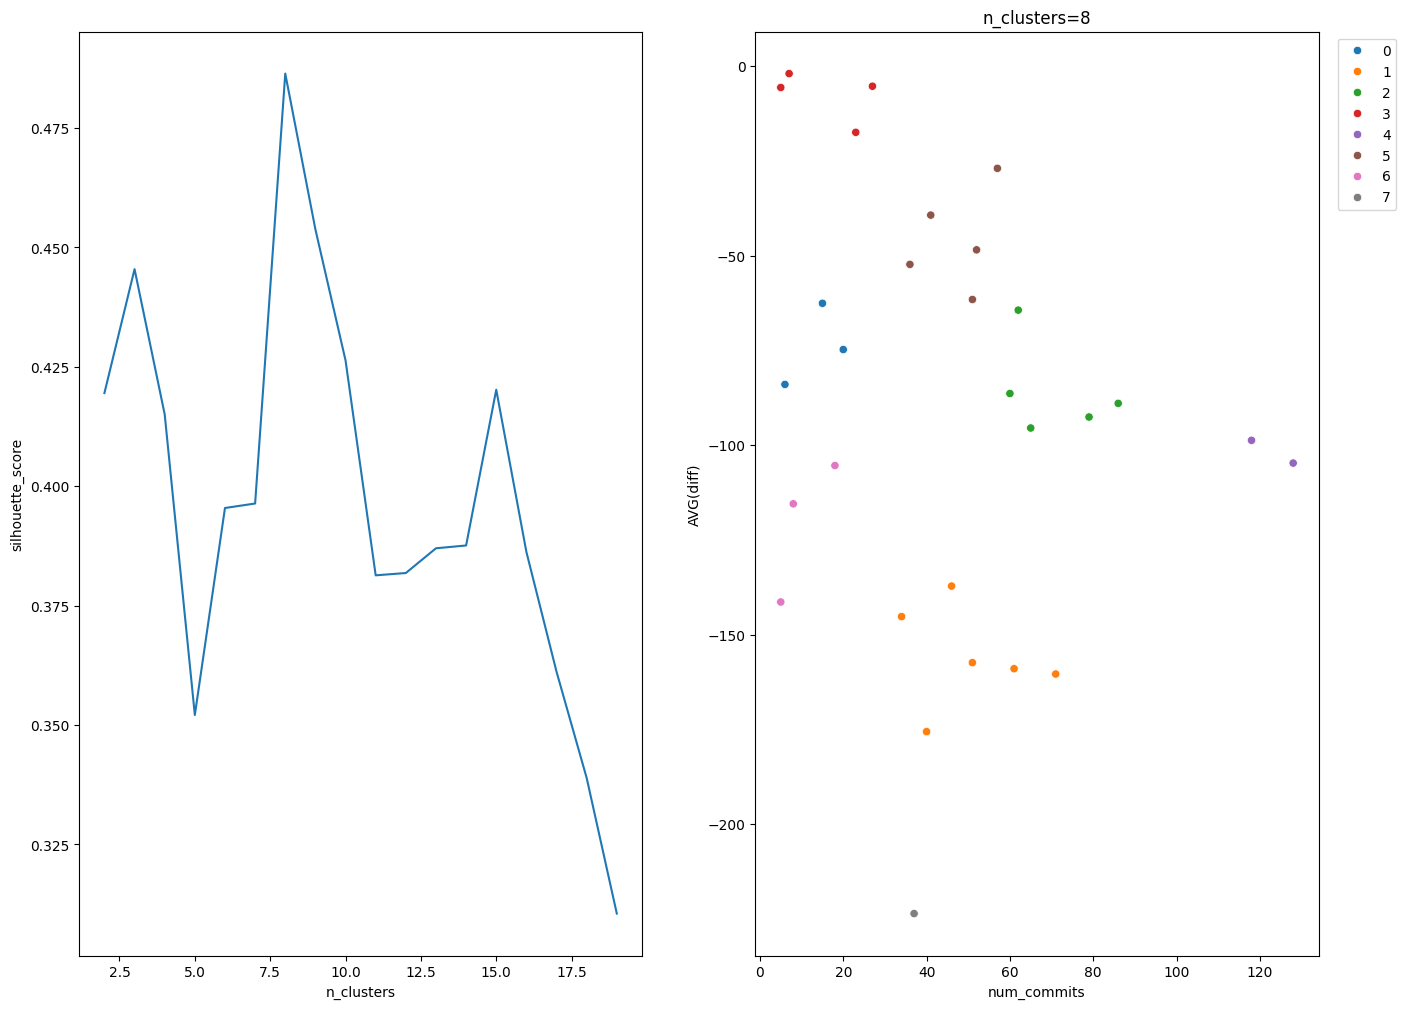

best_value for n_clusters: 8
best_score: 0.48638087320227846


In [15]:
model = KMeans
parameters = {'random_state': 21}
optimized_parameter_name = 'n_clusters'
optimized_parameter_range = range(2, 20)
optimize_clustering(model, X, parameters, optimized_parameter_name, optimized_parameter_range)

*DBSCAN*

/tmp/ipykernel_9273/1393055311.py:35: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  sns.scatterplot(x='num_commits', y='AVG(diff)', data=X, hue=best_labels, palette=palette, ax=ax2)


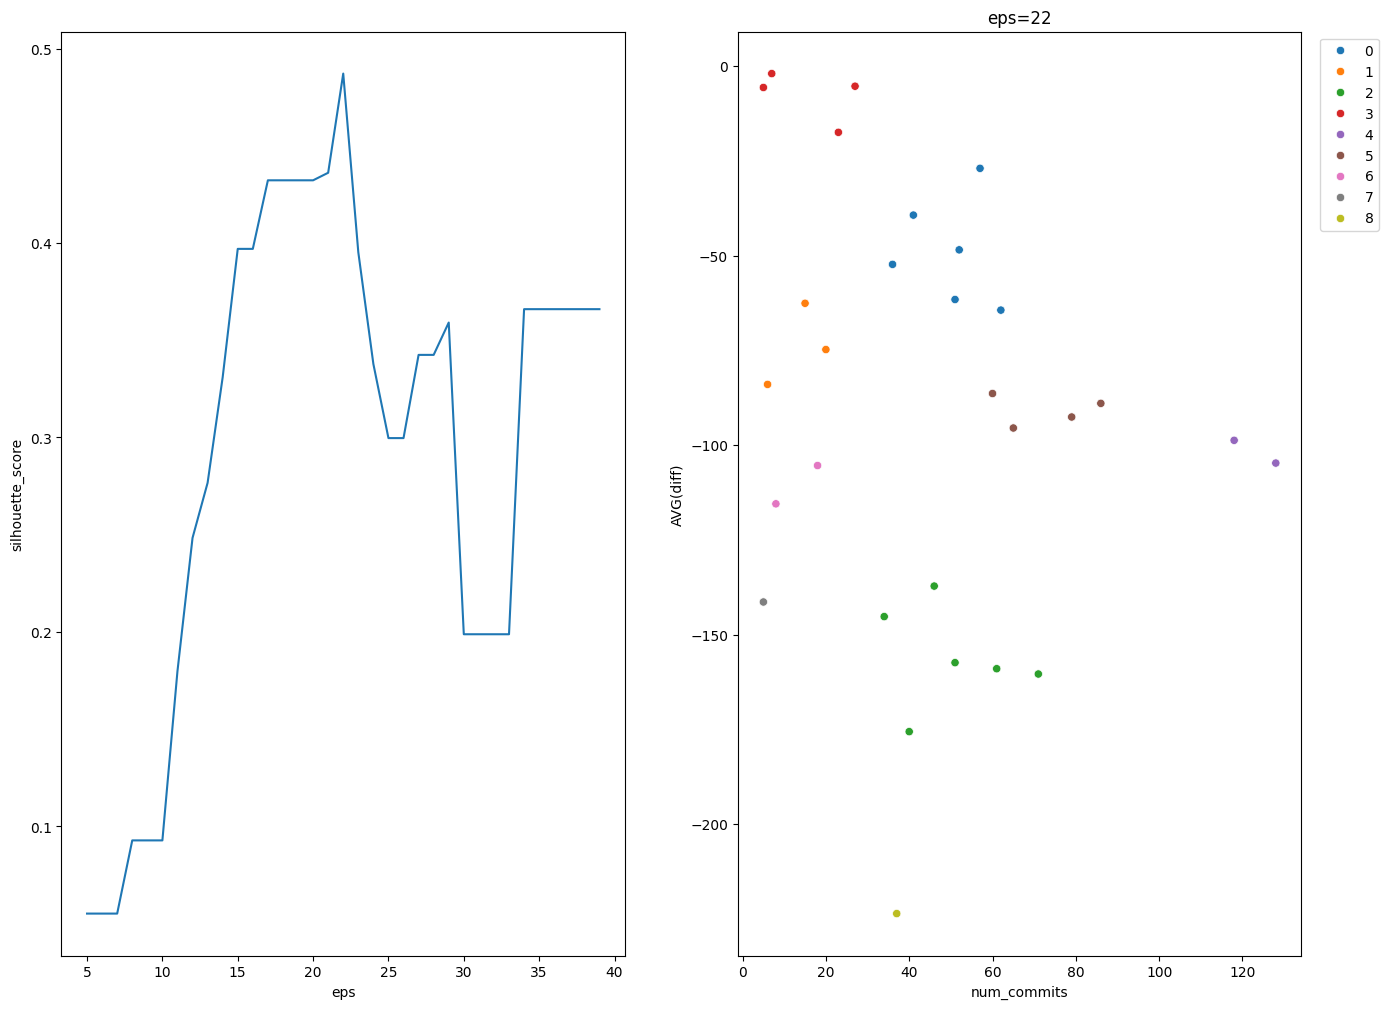

best_value for eps: 22
best_score: 0.48713041554757475


In [16]:
model = DBSCAN
parameters = {'min_samples': 1}
optimized_parameter_name = 'eps'
optimized_parameter_range = range(2, 40)
optimize_clustering(model, X, parameters, optimized_parameter_name, optimized_parameter_range)

/tmp/ipykernel_9273/1393055311.py:35: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  sns.scatterplot(x='num_commits', y='AVG(diff)', data=X, hue=best_labels, palette=palette, ax=ax2)


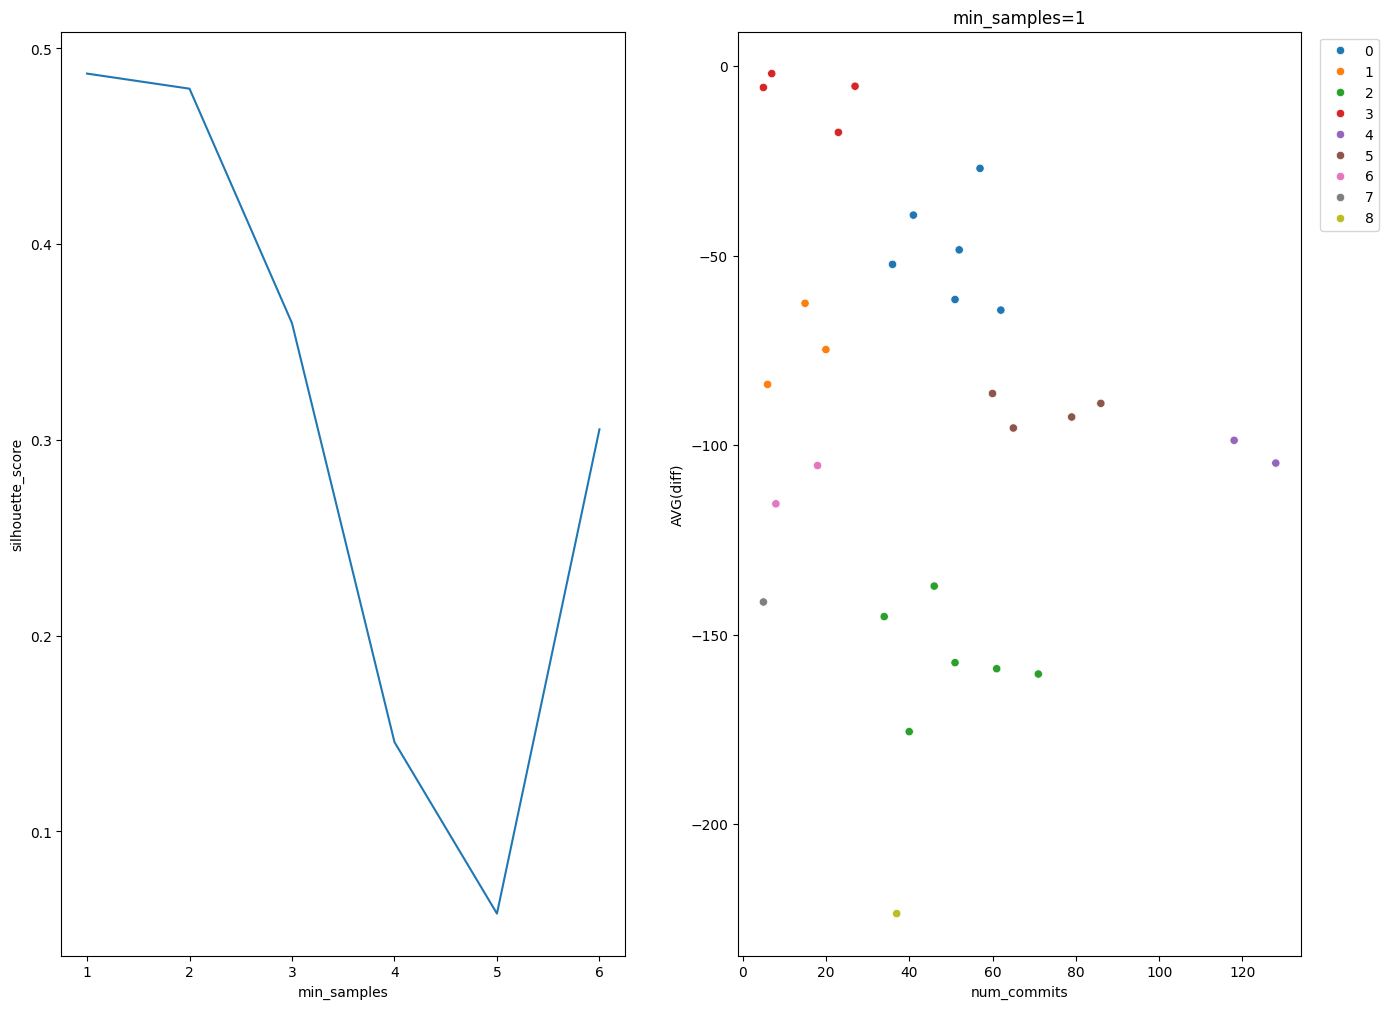

best_value for min_samples: 1
best_score: 0.48713041554757475


In [17]:
model = DBSCAN
parameters = {'eps': 22}
optimized_parameter_name = 'min_samples'
optimized_parameter_range = range(1, 20)
optimize_clustering(model, X, parameters, optimized_parameter_name, optimized_parameter_range)

*AgglomerativeClustering*

/tmp/ipykernel_9273/1393055311.py:35: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.scatterplot(x='num_commits', y='AVG(diff)', data=X, hue=best_labels, palette=palette, ax=ax2)


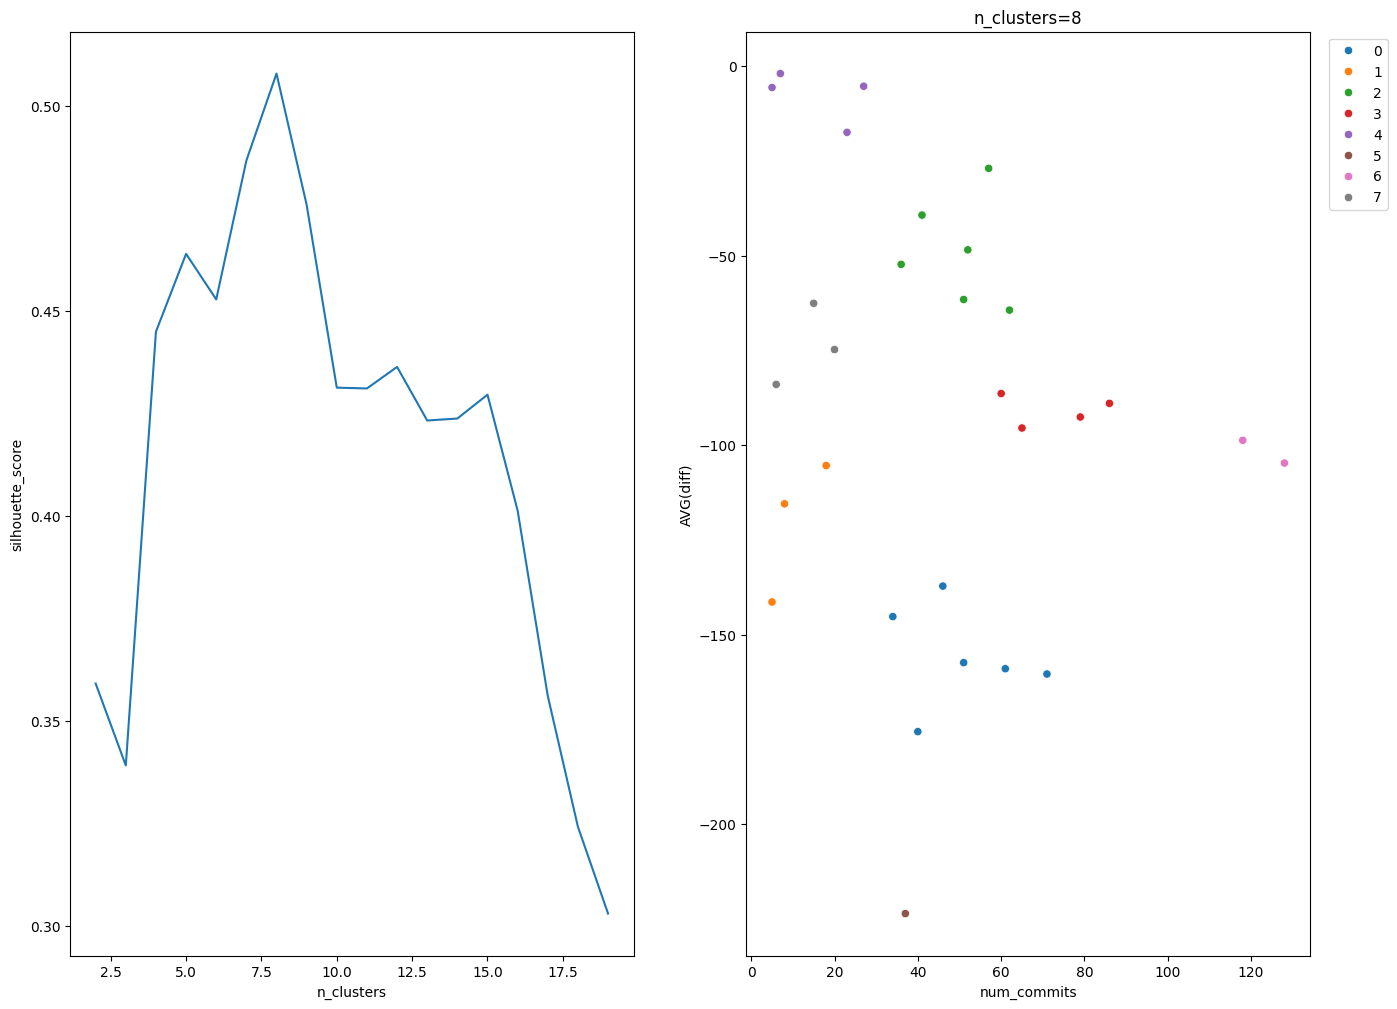

best_value for n_clusters: 8
best_score: 0.50779855565622


In [18]:
model = AgglomerativeClustering
parameters = {}
optimized_parameter_name = 'n_clusters'
optimized_parameter_range = range(2, 20)
optimize_clustering(model, X, parameters, optimized_parameter_name, optimized_parameter_range)